In [1]:
import sys
import os
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from pycgp_finalclass.Config import CGPConfig
from pycgp_finalclass.ES import ES
from pycgp_finalclass.Evaluator import EvaluatorSin, Binary_Classifier, Regressor, MultiClassClassifier,Binary_Regressor
from pycgp_finalclass.Node import Node
from pycgp_finalclass.Mutation import Golden_mutation
from pycgp_finalclass.Function import Func
from pycgp_finalclass.Function_library import *
from pycgp_finalclass.Genome import CGPGenome

def build_funcLib(): #Define the function used
    return [Func(f_sum, 'sum', 2, 0),
            Func(f_aminus, 'aminus', 2, 0),
            Func(f_mult, 'mult', 2, 0),
            Func(f_exp, 'exp', 2, 0),
            Func(f_abs, 'abs', 1, 0),
            Func(f_sqrt, 'sqrt', 1, 0),
            Func(f_sqrtxy, 'sqrtxy', 2, 0),
            Func(f_squared, 'squared', 1, 0),
            Func(f_pow, 'pow', 2, 0),
            Func(f_one, 'one', 0, 0),
            Func(f_zero, 'zero', 0, 0),
            Func(f_const, 'const', 0, 1),
            Func(f_inv, 'inv', 1, 0),
            Func(f_gt, 'gt', 2, 0),
            Func(safe_div, 'div', 2, 0),
            Func(f_asin, 'asin', 1, 0),
            Func(f_acos, 'acos', 1, 0),
            Func(f_atan, 'atan', 1, 0),
            Func(f_sin, 'sin', 1, 0),
            Func(f_min, 'min', 2, 0),
            Func(f_max, 'max', 2, 0),
            Func(f_round, 'round', 1, 0),
            Func(f_floor, 'floor', 1, 0),
            Func(f_ceil, 'ceil', 1, 0)
            ]
functions = build_funcLib()

In [2]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Charger le fichier CSV avec le bon séparateur
file_path = 'datasets/synth_table_av_moy_anthr.csv'
df = pd.read_csv(file_path, sep=';')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# df = your DataFrame with indicators
features = ['ampl', 'f_max', 'sym_max', 'f_Lw1', 'sym_Lw1', 'f_Lw2', 'sym_Lw2',
            'plat_start', 'plat_end', 'plat_med', 'plat_amp', 'slope_pre', 'slope_post','mean_500',	'mean_1000',	'mean_1500',	'mean_2000',	'mean_2500',	'mean_3000',	'mean_3500',	'mean_4000'	,'mean_4500','mean_5000'
]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=0)  # try different k
df['profile'] = kmeans.fit_predict(X_scaled)

profile_summary = df.groupby('profile')[features].mean()
print(profile_summary)

print(df.head(1))


             ampl        f_max   sym_max        f_Lw1   sym_Lw1        f_Lw2  \
profile                                                                        
0       -0.871753  3116.645125  2.095853  3117.079083  1.985465  3268.067028   
1       -3.287982  1301.409383  0.203573  1297.631806  0.201772  1340.700463   
2       -1.972280  1986.985721  0.511083  1995.825589  0.511991  2191.752375   
3        2.256006  1469.672102  0.267486  1478.643640  0.273084  1502.915926   
4       -8.818584  1448.044164  0.272258  1496.239828  0.293785  1498.848529   

          sym_Lw2   plat_start     plat_end     plat_med  ...  mean_500  \
profile                                                   ...             
0        1.653183  2542.860500  3634.548375  3088.704437  ... -5.188896   
1        0.221881  1032.978031  1720.060505  1376.519268  ... -0.622486   
2        0.615238  1627.265359  2713.460266  2170.362813  ... -3.947585   
3        0.278647  1200.982296  1945.580225  1573.281260  ...  2

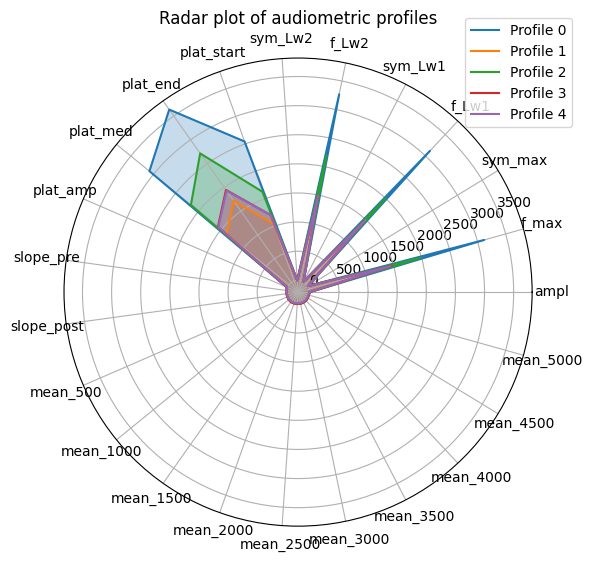

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Average each profile
profile_means = df.groupby('profile')[features].mean()

# Radar chart
labels = features
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Complete the loop

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for i, row in profile_means.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Profile {i}')
    ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.title("Radar plot of audiometric profiles")
plt.tight_layout()
plt.show()


c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\sklearn\utils\_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\sklearn\utils\_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


Starting fitness 0.2481


Early Stop at Gen 5571:  56%|█████▌    | 5571/10000 [20:50<16:33,  4.46gen/s]



Best Train fitness achieved: 0.3068

Test fitness: 0.2575
n132 = sqrtxy(x54, x2)
n133 = gt(n132, n132)
n134 = max(n133, x120)
n135 = round(x7)
n136 = acos(n135)
n137 = ceil(n135)
n138 = sqrt(n137)
n139 = sqrtxy(x53, n136)
n140 = aminus(n133, x97)
n141 = min(n135, n132)
n142 = one()
n143 = const()
n144 = atan(n142)
n145 = ceil(x89)
n146 = exp(n143, x31)
n147 = sum(n133, n143)
n148 = acos(x122)
n149 = aminus(n140, x119)
n150 = atan(n133)
n151 = one()
n152 = round(n139)
n153 = mult(x55, x114)
n154 = atan(n150)
n155 = inv(n132)
n156 = round(n155)
n157 = const()
n158 = div(n155, x32)
n159 = asin(x22)
n160 = one()
n161 = pow(x131, n135)
Outputs: n150, n141, n132, n152, n150

Unrolled output expression 0:
atan(gt(sqrtxy(x54, x2), sqrtxy(x54, x2)))
Unrolled output expression 1:
min(round(x7), sqrtxy(x54, x2))
Unrolled output expression 2:
sqrtxy(x54, x2)
Unrolled output expression 3:
round(sqrtxy(x53, acos(round(x7))))
Unrolled output expression 4:
atan(gt(sqrtxy(x54, x2), sqrtxy(x54, x2)))



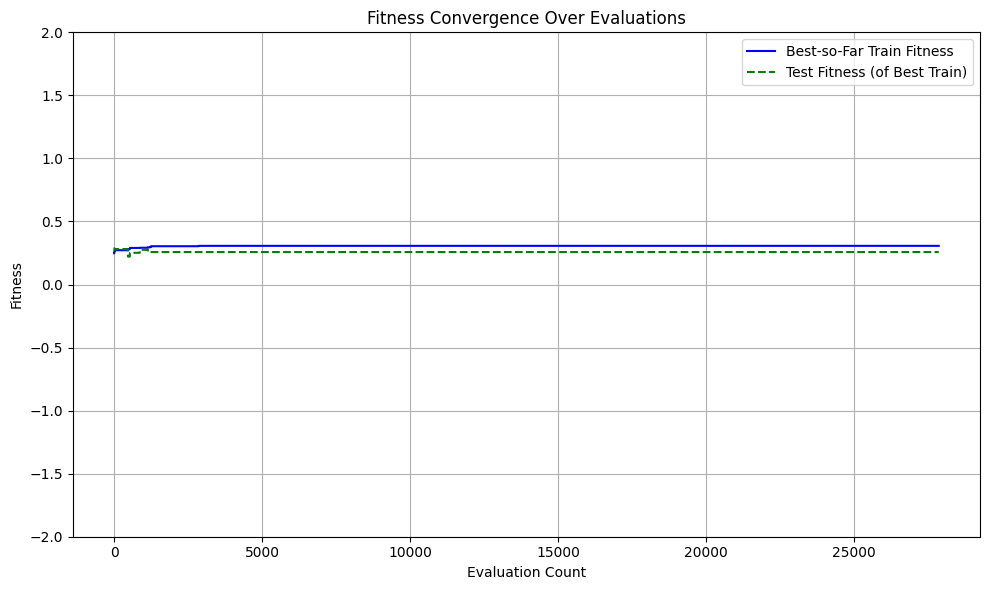

c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\pycgp_finalclass\Genome.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


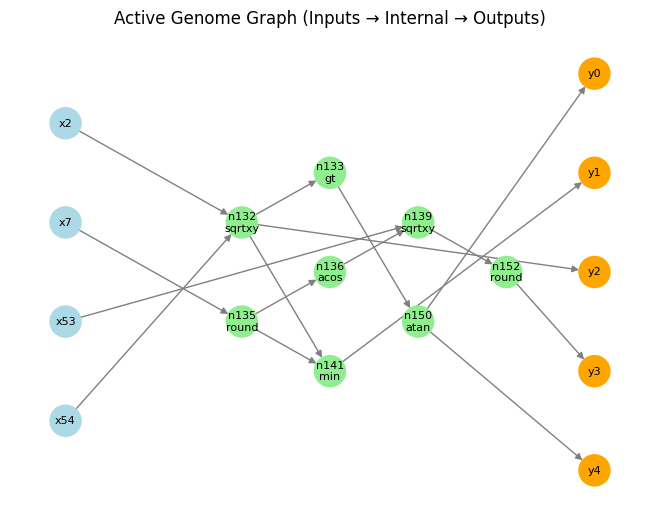

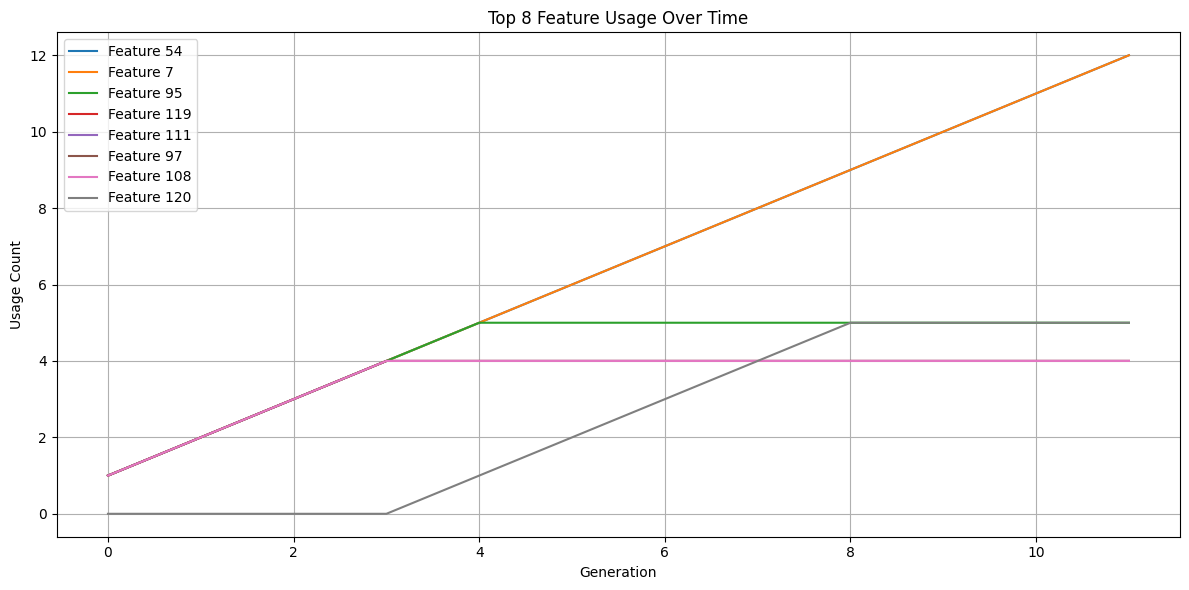

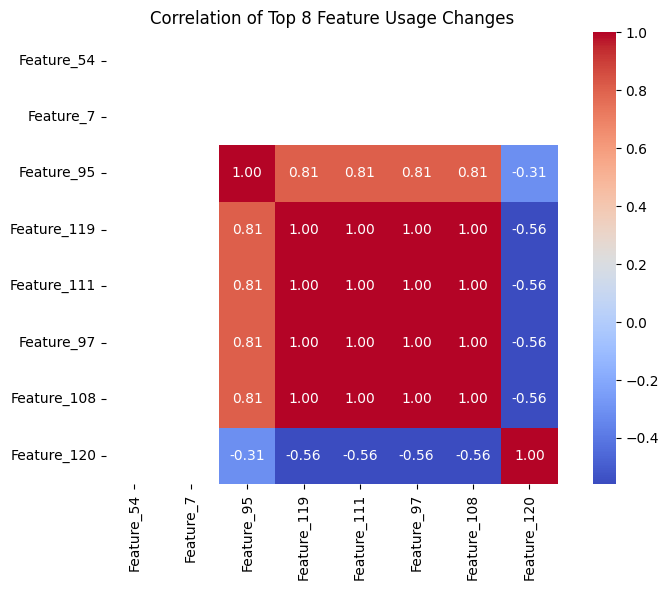

In [4]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.preprocessing import MinMaxScaler




# Cible
y = df['profile']

# Supprimer la colonne cible 'age_class' (vous pouvez aussi la sauvegarder si besoin)
X = df.drop(columns=['ampl', 'f_max', 'sym_max', 'f_Lw1', 'sym_Lw1', 'f_Lw2', 'sym_Lw2',
            'plat_start', 'plat_end', 'plat_med', 'plat_amp', 'slope_pre', 'slope_post','mean_500',	'mean_1000',	'mean_1500',	'mean_2000',	'mean_2500',	'mean_3000',	'mean_3500',	'mean_4000'	,'mean_4500','mean_5000','profile'])

# Encoder toutes les colonnes non-numériques (de type object) en entiers
for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Vérification que tout est bien en float
X = X.astype(float)


scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)

evaluator2 = MultiClassClassifier(X_scaled, y)

#Initialise config + Evaluator + mutation 
CGP_config = CGPConfig(num_inputs=X.shape[1], num_nodes=30, num_outputs=5, input_node_chance=0.4, const_min=-1, const_max=1, function_set=functions)
#For evaluatorsin num_inputs = 1

#mutationcgp_proba = Proba_Mutation(CGP_config, number_mutations=10, input_node_mutation_rate=0.2, output_node_mutation_rate=0.1, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1)
mutationcgp_golden = Golden_mutation(CGP_config,input_node_mutation_rate=0.2, function_mutation_rate=0.4, input_mutation_rate=0.5, const_mutation_rate=0.1,output_node_mutation_rate=0.5)
ES_cgp = ES(evaluator2, lam=5,parent_factory=lambda: CGPGenome.create_genome(CGP_config),mutation = mutationcgp_golden,config = CGP_config)
best_genome = ES_cgp.evolve(n_generations=10000, early_stopping=5000,early_switch=10000, verbose=True)


c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\sklearn\impute\_base.py:635: UserWarning: Skipping features without any observed values: [13 35 59 88]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\pauls\Bureau\Cours_2IS_M2\stage\pyCGP2.0\.venv\Lib\site-packages\sklearn\impute\_base.py:

Logistic Regression: Accuracy = 0.3054
Ridge Classifier: Accuracy = 0.3174
Random Forest: Accuracy = 0.4311
Gradient Boosting: Accuracy = 0.4431
Support Vector Classifier: Accuracy = 0.3413
KNN Classifier: Accuracy = 0.3054

=== Sorted Results ===
                           Accuracy
Gradient Boosting          0.443114
Random Forest              0.431138
Support Vector Classifier  0.341317
Ridge Classifier           0.317365
Logistic Regression        0.305389
KNN Classifier             0.305389

=== CGP result ===
CGP: accuracy score = (0.3067669172932331, 0.25748502994011974)


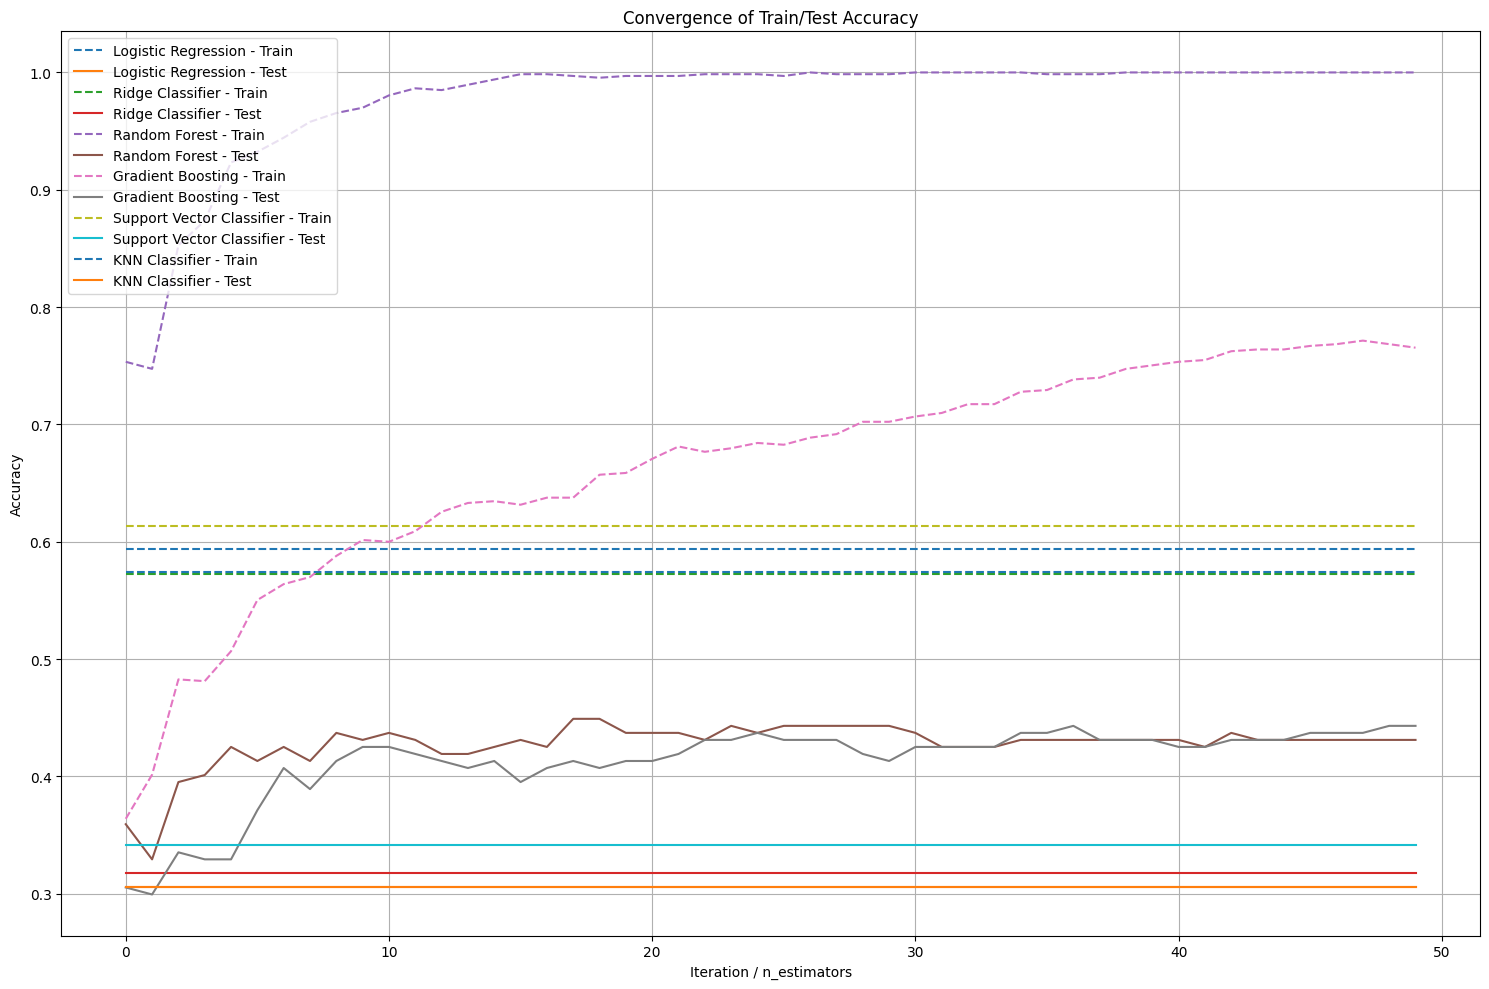

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

# --- Data Preprocessing ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

# --- Models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, warm_start=True),
    'Ridge Classifier': RidgeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=1, warm_start=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=1, warm_start=True, random_state=42),
    'Support Vector Classifier': SVC(),
    'KNN Classifier': KNeighborsClassifier()
}

results = {}
convergence_data = {}

# --- Training Loop with Convergence Tracking ---
for name, model in models.items():
    train_scores = []
    test_scores = []

    if name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']:
        for i in range(1, 51):  # Simulate 50 steps
            if name in ['Random Forest', 'Gradient Boosting']:
                model.n_estimators = i
            model.fit(X_train_imputed, y_train)
            train_acc = model.score(X_train_imputed, y_train)
            test_acc = model.score(X_test_imputed, y_test)
            train_scores.append(train_acc)
            test_scores.append(test_acc)
    else:
        model.fit(X_train_imputed, y_train)
        train_acc = model.score(X_train_imputed, y_train)
        test_acc = model.score(X_test_imputed, y_test)
        train_scores = [train_acc] * 50
        test_scores = [test_acc] * 50

    acc = test_scores[-1]
    results[name] = acc
    convergence_data[name] = (train_scores, test_scores)

    print(f"{name}: Accuracy = {acc:.4f}")

# --- Sorted Results ---
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
df_results = df_results.sort_values('Accuracy', ascending=False)
print("\n=== Sorted Results ===")
print(df_results)

# --- CGP Output ---
print("\n=== CGP result ===")
print(f"CGP: accuracy score = {evaluator2.evaluate(best_genome)}")

# --- Convergence Plots ---
plt.figure(figsize=(15, 10))
for name, (train_scores, test_scores) in convergence_data.items():
    plt.plot(train_scores, label=f'{name} - Train', linestyle='--')
    plt.plot(test_scores, label=f'{name} - Test')

plt.xlabel('Iteration / n_estimators')
plt.ylabel('Accuracy')
plt.title('Convergence of Train/Test Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
